In [1]:
# ====== 1. IMPORT LIBRARY ======
import numpy as np
import pandas as pd

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from time import time

print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [2]:
# ====== 2. LOAD DATA ======
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/SKRIPSI/kode/transaksi_lkpp_realistic_6000.csv'
df = pd.read_csv(file_path)

# Parsing tanggal
df['Tanggal'] = pd.to_datetime(df['Tanggal'], errors='coerce')

# Pisahkan fitur & label
y = df['Is_Anomaly'].astype(int)
X = df.drop(columns=['Is_Anomaly'])

print("Shape data:", X.shape)
print("Jumlah anomali:", int(y.sum()), "dari", len(y))

print("DATA AWAL")
display(X.head(10))


Mounted at /content/drive
Shape data: (6000, 6)
Jumlah anomali: 300 dari 6000
DATA AWAL


,Tanggal,Rekening_Asal,Rekening_Tujuan,Jumlah,Jenis_Belanja,Deskripsi
0,2023-08-03,ACC_KEMENESDM_020_331,ACC_SOS_027_459,6.675326e+09,Belanja Barang,Pengadaan barang operasional
1,2023-04-10,ACC_PPATK_078_872,ACC_POLRI_060_664,1.697694e+10,Belanja Bantuan Sosial,Bansos tunai
2,2023-10-21,ACC_BPK_004_386,ACC_ESDM_020_192,1.877669e+10,Belanja Pembayaran Bunga Utang,Pembayaran bunga SBN
3,2023-06-10,ACC_BRIN_124_460,ACC_PPATK_078_314,9.631824e+09,Belanja Lain-lain,Belanja lainnya sesuai ketentuan
4,2023-02-28,ACC_KEMENAG_025_511,ACC_BPS_054_682,5.308406e+09,Belanja Pembayaran Bunga Utang,Pembayaran bunga SBN
5,2023-07-07,ACC_KEU_015_976,ACC_KES_024_783,6.954310e+09,Belanja Pegawai,Tunjangan kinerja triwulan
6,2023-02-24,ACC_BPK_004_244,ACC_KEMENDIKBUD_023_832,1.185980e+10,Belanja Modal,Pembangunan infrastruktur jalan
7,2023-11-03,ACC_KEU_015_647,ACC_KEMENHUB_022_021,3.165546e+10,Belanja Modal,Pengadaan peralatan dan mesin
8,2023-12-12,ACC_BPJS_NA_565,ACC_KEMENESDM_020_898,3.878151e+09,Belanja Modal,Pembangunan infrastruktur jalan
9,2023-09-21,ACC_BPS_054_943,ACC_BPK_004_035,3.887420e+10,Belanja Pembayaran Bunga Utang,Pembayaran kupon SUN


In [3]:
# ---- PEMBERSIHAN DATA ----
df_clean = df.copy()

# Validasi jumlah transaksi (harus > 0)
df_clean = df_clean[df_clean['Jumlah'] > 0]

# Hapus baris dengan tanggal invalid
df_clean = df_clean.dropna(subset=['Tanggal'])

# Pastikan tipe data numerik
df_clean['Jumlah'] = df_clean['Jumlah'].astype(float)

print("Data sebelum cleaning :", df.shape)
print("Data setelah cleaning :", df_clean.shape)

display(df_clean.head(10))


Data sebelum cleaning : (6000, 7)
Data setelah cleaning : (6000, 7)


,Tanggal,Rekening_Asal,Rekening_Tujuan,Jumlah,Jenis_Belanja,Deskripsi,Is_Anomaly
0,2023-08-03,ACC_KEMENESDM_020_331,ACC_SOS_027_459,6.675326e+09,Belanja Barang,Pengadaan barang operasional,0
1,2023-04-10,ACC_PPATK_078_872,ACC_POLRI_060_664,1.697694e+10,Belanja Bantuan Sosial,Bansos tunai,0
2,2023-10-21,ACC_BPK_004_386,ACC_ESDM_020_192,1.877669e+10,Belanja Pembayaran Bunga Utang,Pembayaran bunga SBN,0
3,2023-06-10,ACC_BRIN_124_460,ACC_PPATK_078_314,9.631824e+09,Belanja Lain-lain,Belanja lainnya sesuai ketentuan,0
4,2023-02-28,ACC_KEMENAG_025_511,ACC_BPS_054_682,5.308406e+09,Belanja Pembayaran Bunga Utang,Pembayaran bunga SBN,0
5,2023-07-07,ACC_KEU_015_976,ACC_KES_024_783,6.954310e+09,Belanja Pegawai,Tunjangan kinerja triwulan,0
6,2023-02-24,ACC_BPK_004_244,ACC_KEMENDIKBUD_023_832,1.185980e+10,Belanja Modal,Pembangunan infrastruktur jalan,0
7,2023-11-03,ACC_KEU_015_647,ACC_KEMENHUB_022_021,3.165546e+10,Belanja Modal,Pengadaan peralatan dan mesin,0
8,2023-12-12,ACC_BPJS_NA_565,ACC_KEMENESDM_020_898,3.878151e+09,Belanja Modal,Pembangunan infrastruktur jalan,0
9,2023-09-21,ACC_BPS_054_943,ACC_BPK_004_035,3.887420e+10,Belanja Pembayaran Bunga Utang,Pembayaran kupon SUN,0


In [4]:
# ====== 3. REKAYASA FITUR KONTEKSTUAL AUDIT (ANTI-LEAKAGE) ======
class AuditFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    @staticmethod
    def extract_instansi(acc):
        try:
            # Contoh: ACC_KEMENESDM_020_331 -> 'KEMENESDM'
            return str(acc).split('_')[1]
        except Exception:
            return 'UNK'

    def fit(self, X, y=None):
        X = X.copy()

        # Agregasi hanya dari TRAIN (untuk hindari leakage)
        self.total_by_asal_ = X.groupby('Rekening_Asal')['Jumlah'].sum()
        self.total_by_jenis_ = X.groupby('Jenis_Belanja')['Jumlah'].sum()

        # Frekuensi rekening (opsional tapi bagus)
        self.freq_asal_ = X['Rekening_Asal'].value_counts()
        self.freq_tujuan_ = X['Rekening_Tujuan'].value_counts()
        return self

    def transform(self, X):
        X = X.copy()

        # ---------- 3.1 Fitur Temporal ----------
        X['Tahun'] = X['Tanggal'].dt.year.astype('Int64').astype(str)
        X['Bulan'] = X['Tanggal'].dt.month.astype('Int64').astype(str)
        X['Triwulan'] = 'Q' + X['Tanggal'].dt.quarter.astype('Int64').astype(str)

        # ---------- 3.2 Fitur Instansi (abstraksi rekening) ----------
        X['Instansi_Asal'] = X['Rekening_Asal'].apply(self.extract_instansi)
        X['Instansi_Tujuan'] = X['Rekening_Tujuan'].apply(self.extract_instansi)
        X['Same_Instansi'] = (X['Instansi_Asal'] == X['Instansi_Tujuan']).astype(int)

        # ---------- 3.3 Fitur jumlah & rasio (berdasarkan TRAIN) ----------
        X['Log_Jumlah'] = np.log1p(X['Jumlah'])

        # map total dari TRAIN; kalau ada rekening/jenis baru di test -> NaN -> 0
        denom_asal = X['Rekening_Asal'].map(self.total_by_asal_)
        denom_jenis = X['Jenis_Belanja'].map(self.total_by_jenis_)

        X['Rasio_Jumlah_vs_Asal'] = X['Jumlah'] / denom_asal
        X['Rasio_Jumlah_vs_Jenis'] = X['Jumlah'] / denom_jenis

        # ---------- 3.4 Frekuensi rekening (berdasarkan TRAIN) ----------
        X['Freq_Asal'] = X['Rekening_Asal'].map(self.freq_asal_)
        X['Freq_Tujuan'] = X['Rekening_Tujuan'].map(self.freq_tujuan_)

        # ---------- 3.5 Deskripsi jadi fitur aman (bukan teks mentah) ----------
        X['Panjang_Deskripsi'] = X['Deskripsi'].astype(str).str.len()

        # Bersihkan inf/nan
        fix_cols = [
            'Rasio_Jumlah_vs_Asal', 'Rasio_Jumlah_vs_Jenis',
            'Freq_Asal', 'Freq_Tujuan'
        ]
        X[fix_cols] = X[fix_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

        # DROP kolom mentah yang menyebabkan dimensi meledak / noise
        X = X.drop(columns=['Tanggal', 'Rekening_Asal', 'Rekening_Tujuan', 'Deskripsi'])

        return X


In [5]:
# ====== 4. TRAIN–TEST SPLIT (WAJIB SEBELUM FIT PIPELINE) ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

anomaly_rate = float(y_train.mean())  # ~0.05
print("Rasio anomali di train:", anomaly_rate)

Rasio anomali di train: 0.05


In [6]:
# ====== 5. DEFINISI FITUR SETELAH REKAYASA ======
numeric_features = [
    'Jumlah',
    'Log_Jumlah',
    'Rasio_Jumlah_vs_Asal',
    'Rasio_Jumlah_vs_Jenis',
    'Same_Instansi',
    'Freq_Asal',
    'Freq_Tujuan',
    'Panjang_Deskripsi'
]

categorical_features = [
    'Jenis_Belanja',
    'Instansi_Asal',
    'Instansi_Tujuan',
    'Tahun',
    'Bulan',
    'Triwulan'
]

In [7]:
# ====== 6. PREPROCESSING (SPARSE) + SVD
# 1.6.1 -> gunakan sparse_output
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot)
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

# SVD untuk sparse matrix
svd = TruncatedSVD(n_components=50, random_state=42)

full_pipeline = Pipeline(steps=[
    ('feature_engineering', AuditFeatureEngineer()),
    ('preprocessor', preprocessor),
    ('svd', svd)
])

# Transform data
X_train_red = full_pipeline.fit_transform(X_train, y_train)
X_test_red = full_pipeline.transform(X_test)

print("Shape train setelah SVD:", X_train_red.shape)
print("Shape test  setelah SVD:", X_test_red.shape)

Shape train setelah SVD: (4200, 50)
Shape test  setelah SVD: (1800, 50)


In [8]:
# ====== 7. MODEL 1: ISOLATION FOREST ======
iso = IsolationForest(
    n_estimators=400,
    max_samples='auto',
    contamination=anomaly_rate,
    max_features=0.8,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

t0 = time()
iso.fit(X_train_red)
train_time_if = time() - t0

t0 = time()
scores_if = -iso.decision_function(X_test_red)
pred_if = (iso.predict(X_test_red) == -1).astype(int)
infer_time_if = time() - t0

auc_if = roc_auc_score(y_test, scores_if) if len(np.unique(y_test)) > 1 else np.nan
acc_if = accuracy_score(y_test, pred_if)
recall_if = recall_score(y_test, pred_if, zero_division=0)
precision_if = precision_score(y_test, pred_if, zero_division=0)
f1_if = f1_score(y_test, pred_if, zero_division=0)

print("\n================ Isolation Forest (Audit-aware) ================")
print("Accuracy :", acc_if)
print("AUC      :", auc_if)
print("Recall   :", recall_if)
print("Precision:", precision_if)
print("F1-score :", f1_if)
print("Train time (s):", train_time_if)
print("Infer time (s):", infer_time_if)

print("\nConfusion Matrix (IF):")
print(confusion_matrix(y_test, pred_if))

print("\nClassification Report (IF):")
print(classification_report(y_test, pred_if, digits=4, zero_division=0))



================ Isolation Forest (Audit-aware) ================
Accuracy : 0.8883333333333333
AUC      : 0.5341390513320338
Recall   : 0.12222222222222222
Precision: 0.08270676691729323
F1-score : 0.09865470852017937
Train time (s): 2.223483085632324
Infer time (s): 0.4473612308502197

Confusion Matrix (IF):
[[1588  122]
 [  79   11]]

Classification Report (IF):
              precision    recall  f1-score   support

           0     0.9526    0.9287    0.9405      1710
           1     0.0827    0.1222    0.0987        90

    accuracy                         0.8883      1800
   macro avg     0.5177    0.5254    0.5196      1800
weighted avg     0.9091    0.8883    0.8984      1800



In [9]:
# ====== 8. MODEL 2: LOCAL OUTLIER FACTOR (novelty) ======
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=anomaly_rate,
    novelty=True,
    n_jobs=-1
)

t0 = time()
lof.fit(X_train_red)
train_time_lof = time() - t0

t0 = time()
scores_lof = -lof.decision_function(X_test_red)
pred_lof = (lof.predict(X_test_red) == -1).astype(int)
infer_time_lof = time() - t0

auc_lof = roc_auc_score(y_test, scores_lof) if len(np.unique(y_test)) > 1 else np.nan
acc_lof = accuracy_score(y_test, pred_lof)
recall_lof = recall_score(y_test, pred_lof, zero_division=0)
precision_lof = precision_score(y_test, pred_lof, zero_division=0)
f1_lof = f1_score(y_test, pred_lof, zero_division=0)

print("\n================ Local Outlier Factor (Audit-aware) ================")
print("Accuracy :", acc_lof)
print("AUC      :", auc_lof)
print("Recall   :", recall_lof)
print("Precision:", precision_lof)
print("F1-score :", f1_lof)
print("Train time (s):", train_time_lof)
print("Infer time (s):", infer_time_lof)

print("\nConfusion Matrix (LOF):")
print(confusion_matrix(y_test, pred_lof))

print("\nClassification Report (LOF):")
print(classification_report(y_test, pred_lof, digits=4, zero_division=0))


================ Local Outlier Factor (Audit-aware) ================
Accuracy : 0.7088888888888889
AUC      : 0.543879142300195
Recall   : 0.2777777777777778
Precision: 0.05165289256198347
F1-score : 0.08710801393728224
Train time (s): 0.35836338996887207
Infer time (s): 0.26702404022216797

Confusion Matrix (LOF):
[[1251  459]
 [  65   25]]

Classification Report (LOF):
              precision    recall  f1-score   support

           0     0.9506    0.7316    0.8268      1710
           1     0.0517    0.2778    0.0871        90

    accuracy                         0.7089      1800
   macro avg     0.5011    0.5047    0.4570      1800
weighted avg     0.9057    0.7089    0.7898      1800



In [10]:
# ====== 9. RINGKASAN KOMPARASI MODEL ======
results = pd.DataFrame([
    {
        "Model": "Isolation Forest (Audit-aware)",
        "Accuracy": round(acc_if, 4),
        "AUC-ROC": round(auc_if, 4),
        "Recall": round(recall_if, 4),
        "Precision": round(precision_if, 4),
        "F1-Score": round(f1_if, 4),
        "Train Time (s)": round(train_time_if, 4),
        "Inference Time (s)": round(infer_time_if, 4)
    },
    {
        "Model": "LOF (Audit-aware)",
        "Accuracy": round(acc_lof, 4),
        "AUC-ROC": round(auc_lof, 4),
        "Recall": round(recall_lof, 4),
        "Precision": round(precision_lof, 4),
        "F1-Score": round(f1_lof, 4),
        "Train Time (s)": round(train_time_lof, 4),
        "Inference Time (s)": round(infer_time_lof, 4)
    }
])

print("\n================ Ringkasan IF vs LOF (Audit-aware) ================")
display(results)



================ Ringkasan IF vs LOF (Audit-aware) ================


,Model,Accuracy,AUC-ROC,Recall,Precision,F1-Score,Train Time (s),Inference Time (s)
0,Isolation Forest (Audit-aware),0.8883,0.5341,0.1222,0.0827,0.0987,2.2235,0.4474
1,LOF (Audit-aware),0.7089,0.5439,0.2778,0.0517,0.0871,0.3584,0.2670


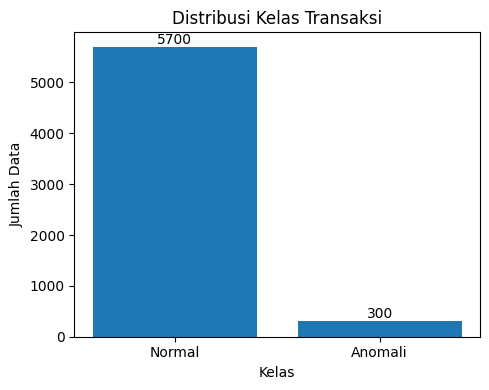

In [11]:
import matplotlib.pyplot as plt

labels = ['Normal', 'Anomali']
counts = [int((y == 0).sum()), int((y == 1).sum())]

plt.figure(figsize=(5,4))
plt.bar(labels, counts)
plt.title("Distribusi Kelas Transaksi")
plt.ylabel("Jumlah Data")
plt.xlabel("Kelas")
for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')
plt.tight_layout()
plt.show()


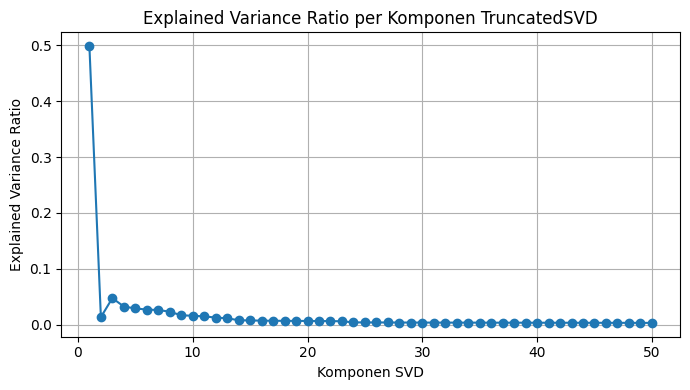

In [12]:
evr = svd.explained_variance_ratio_

plt.figure(figsize=(7,4))
plt.plot(range(1, len(evr)+1), evr, marker='o')
plt.title("Explained Variance Ratio per Komponen TruncatedSVD")
plt.xlabel("Komponen SVD")
plt.ylabel("Explained Variance Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()


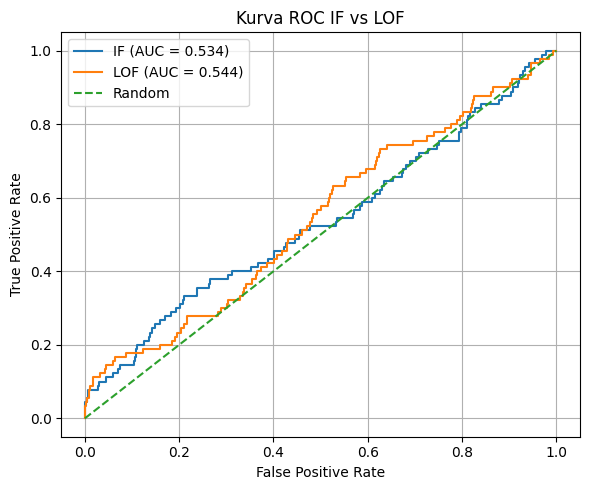

In [13]:
from sklearn.metrics import roc_curve, auc

fpr_if, tpr_if, _ = roc_curve(y_test, scores_if)
fpr_lof, tpr_lof, _ = roc_curve(y_test, scores_lof)

plt.figure(figsize=(6,5))
plt.plot(fpr_if, tpr_if, label=f"IF (AUC = {auc_if:.3f})")
plt.plot(fpr_lof, tpr_lof, label=f"LOF (AUC = {auc_lof:.3f})")
plt.plot([0,1], [0,1], linestyle='--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Kurva ROC IF vs LOF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


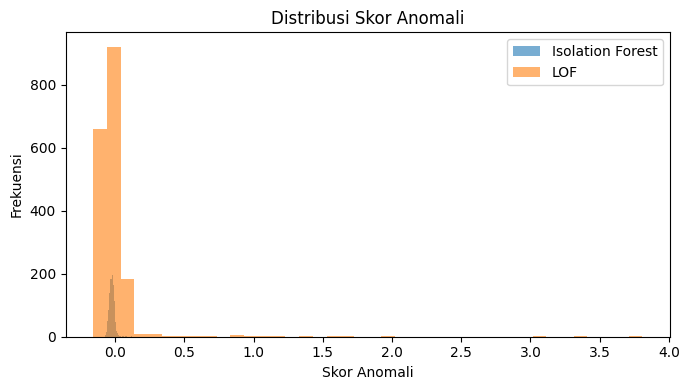

In [14]:
plt.figure(figsize=(7,4))
plt.hist(scores_if, bins=40, alpha=0.6, label="Isolation Forest")
plt.hist(scores_lof, bins=40, alpha=0.6, label="LOF")
plt.title("Distribusi Skor Anomali")
plt.xlabel("Skor Anomali")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()


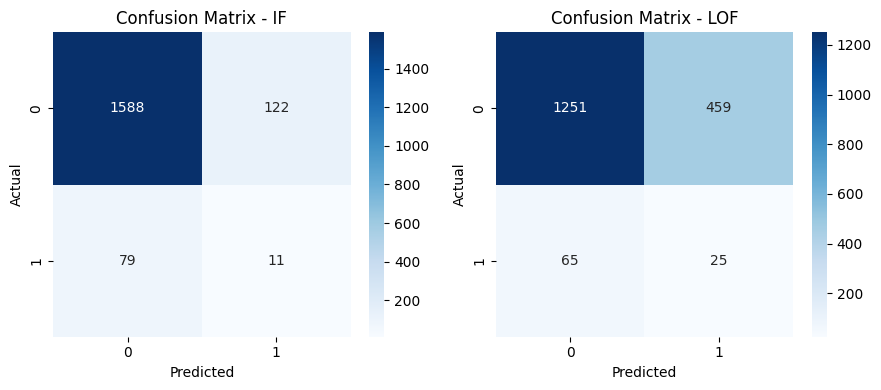

In [16]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_if = confusion_matrix(y_test, pred_if)
cm_lof = confusion_matrix(y_test, pred_lof)

fig, axes = plt.subplots(1, 2, figsize=(9,4))

sns.heatmap(cm_if, annot=True, fmt='d', ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix - IF")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_lof, annot=True, fmt='d', ax=axes[1], cmap="Blues")
axes[1].set_title("Confusion Matrix - LOF")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


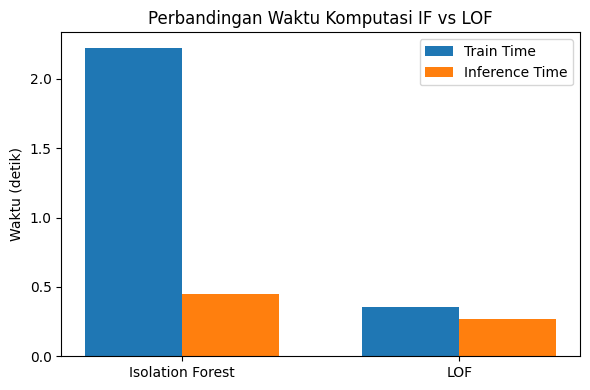

In [17]:
models = ['Isolation Forest', 'LOF']
train_times = [train_time_if, train_time_lof]
infer_times = [infer_time_if, infer_time_lof]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(6,4))
plt.bar(x - width/2, train_times, width, label='Train Time')
plt.bar(x + width/2, infer_times, width, label='Inference Time')

plt.xticks(x, models)
plt.ylabel("Waktu (detik)")
plt.title("Perbandingan Waktu Komputasi IF vs LOF")
plt.legend()
plt.tight_layout()
plt.show()
